# Parallel Analysis


In [1]:
from pathlib import Path
import os
import re

import numpy as np
import pandas as pd

from HW_HD_utils import *
from plots_utils import *
from create_npy_file import create_npy_file, create_grouped_npy_files, create_npy_file_truncated

no_instructions = 5000


In [2]:
parallel_registers = ["r0", "r1", "r2", "r3", "r4", "r5", "r6", "r7", "r8", "r9", "r10", "r11", "r12", "sp", "lr"]
parallel_trace_dir = "output_decapsulation_parallel_TRIM"
result_dir = "Results_decapsulation_parallel"
no_instructions = 500
reset_folder(result_dir)

reset_result_dir = False
if reset_result_dir:
    reset_folder(result_dir)
os.makedirs(result_dir, exist_ok=True)

create_npy_file(f"{result_dir}/RESULTS_HW", parallel_trace_dir, "HW", parallel_registers)
create_npy_file(f"{result_dir}/RESULTS_HD", parallel_trace_dir, "HD", parallel_registers)


Creating simulation traces model.... HW
Trace 0 has been converted
Trace 100 has been converted
Trace 200 has been converted
Trace 300 has been converted
Trace 400 has been converted
Trace 500 has been converted
Trace 600 has been converted
The last trace that was captured is Trace 641
Finished creating Results_decapsulation_parallel/RESULTS_HW.npy, shape = (641, 29237)
Creating simulation traces model.... HD
Trace 0 has been converted
Trace 100 has been converted
Trace 200 has been converted
Trace 300 has been converted
Trace 400 has been converted
Trace 500 has been converted
Trace 600 has been converted
The last trace that was captured is Trace 641
Finished creating Results_decapsulation_parallel/RESULTS_HD.npy, shape = (641, 29236)


In [3]:
filename_hw = f"{result_dir}/RESULTS_HW.npy"
filename_hd = f"{result_dir}/RESULTS_HD.npy"

data_HW = np.load(filename_hw)
data_HD = np.load(filename_hd)

information(data_HW)
information(data_HD)


The shape of the data is: (641, 29237)
The type of the data is: float64
The first 2 traces are: [[ 80.  82.  83. ... 145. 135. 136.]
 [ 80.  82.  83. ... 146. 136. 137.]]
If there are any NaN values: False
The shape of the data is: (641, 29236)
The type of the data is: float64
The first 2 traces are: [[ 2.  1.  9. ...  0. 28.  7.]
 [ 2.  1.  9. ...  0. 28.  7.]]
If there are any NaN values: False


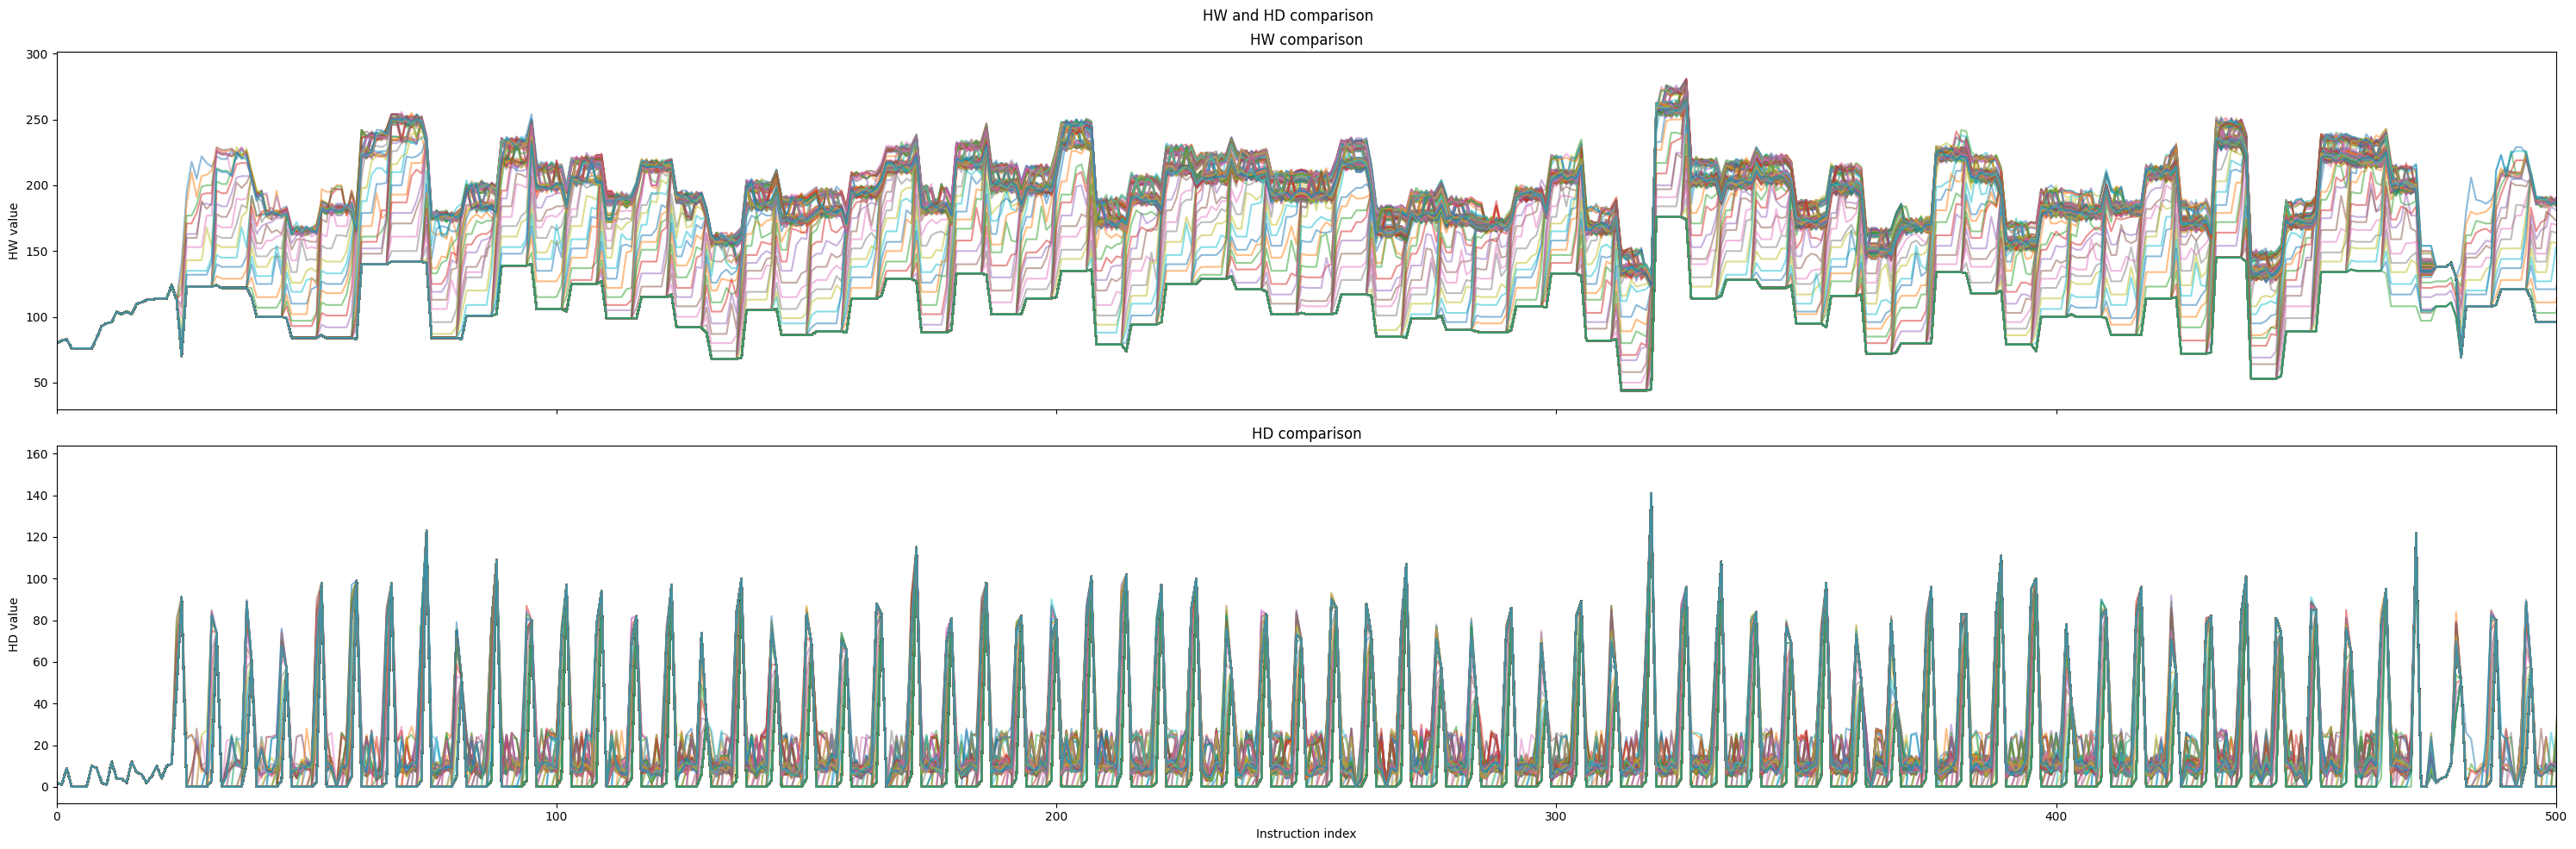

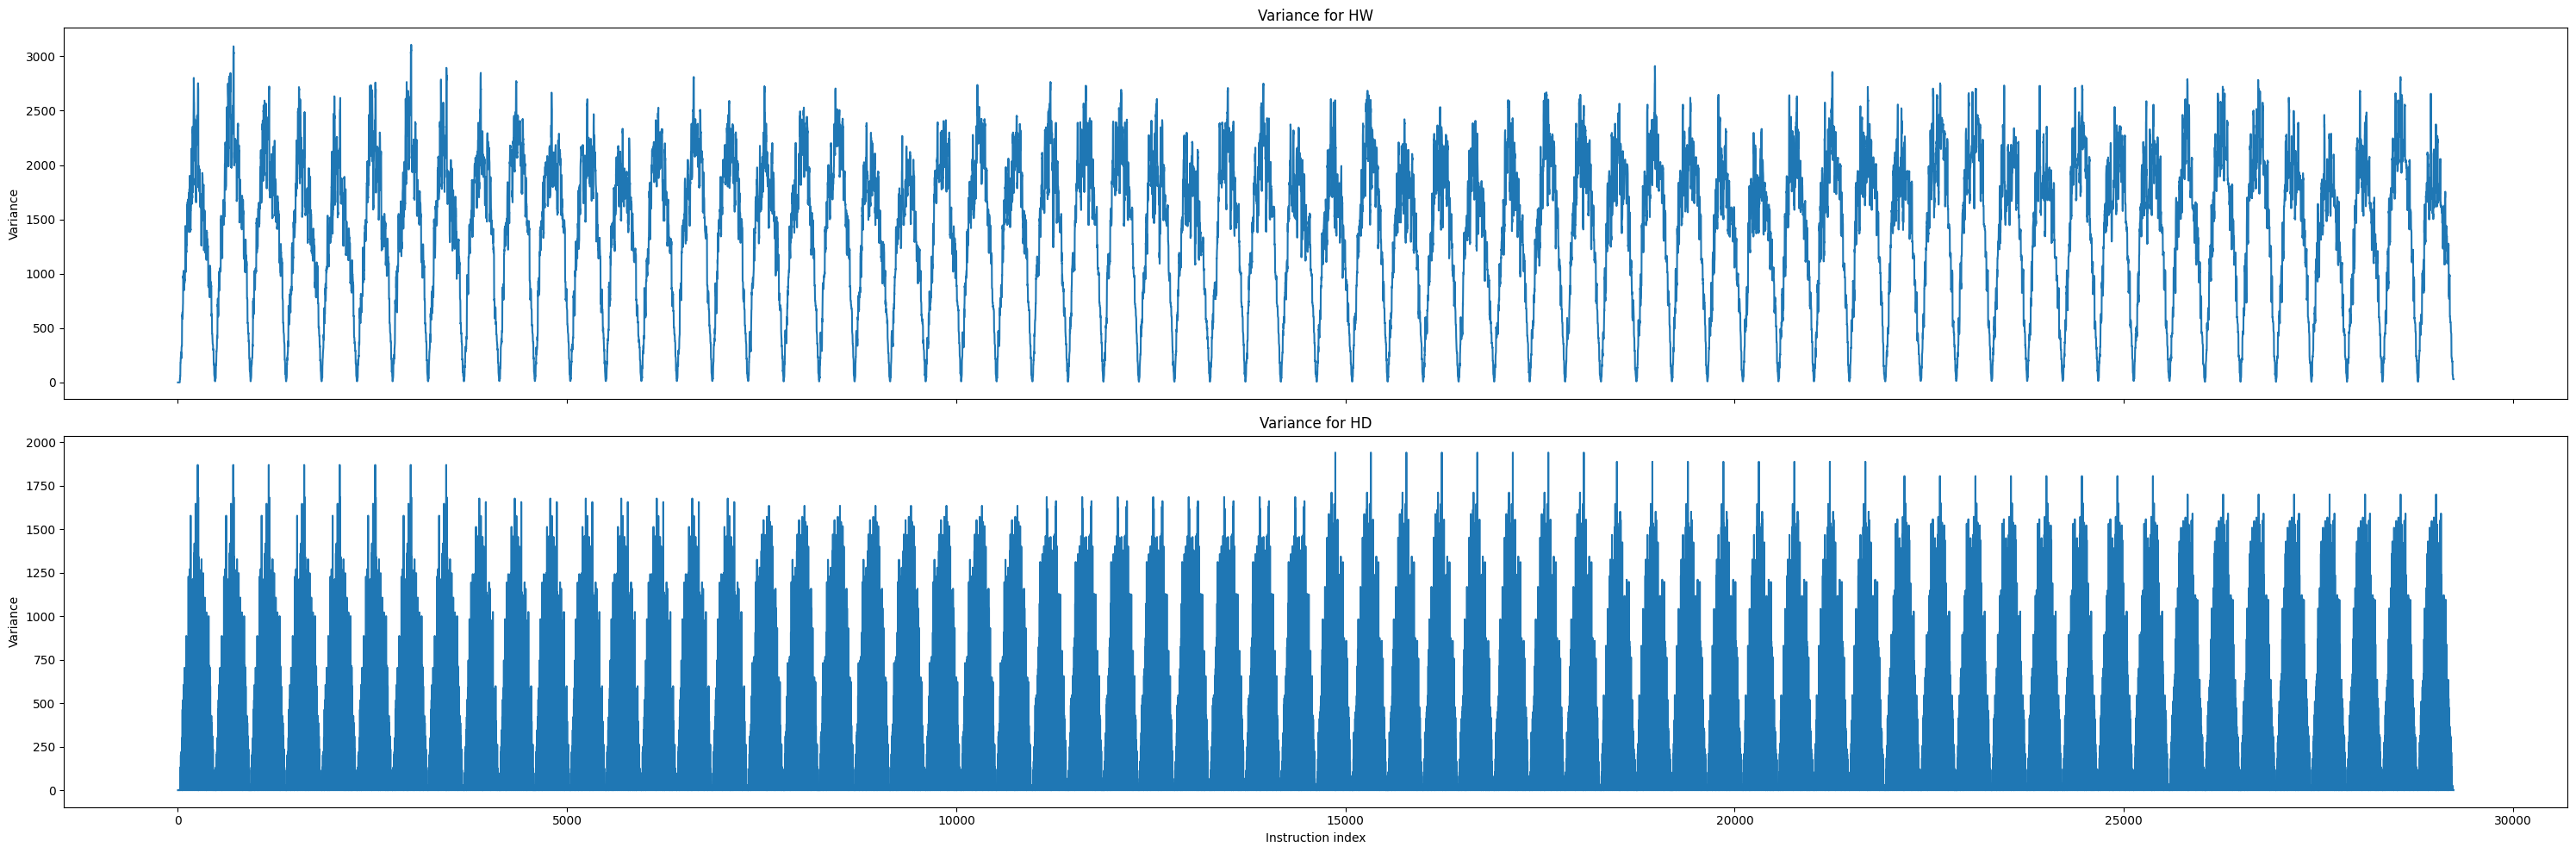

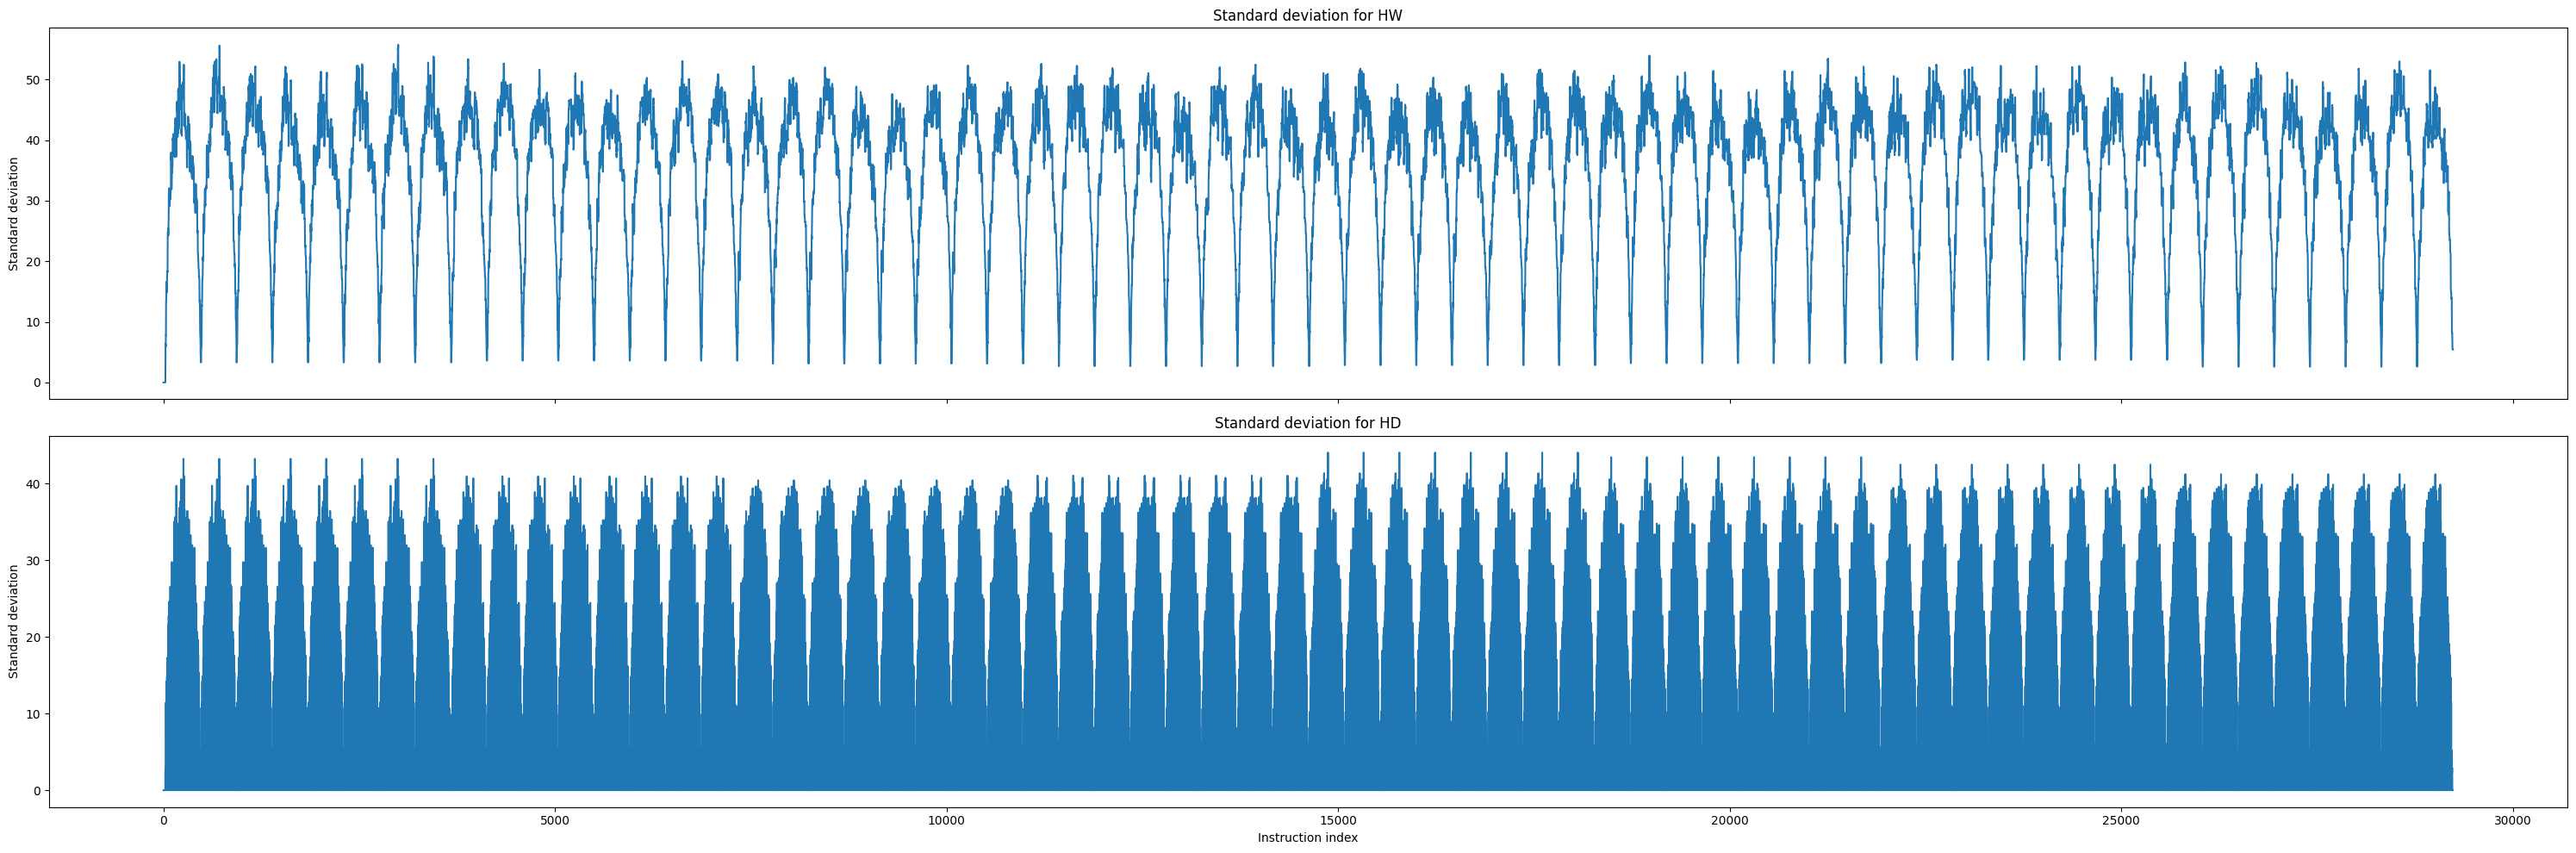

In [4]:
plot_hw_hd_comparison(data_HW, data_HD, save_path=os.path.join(result_dir, "traces_plot.png"), no_instructions=no_instructions)
plot_variance_and_std(data_HW, data_HD, result_dir, no_instructions=no_instructions)


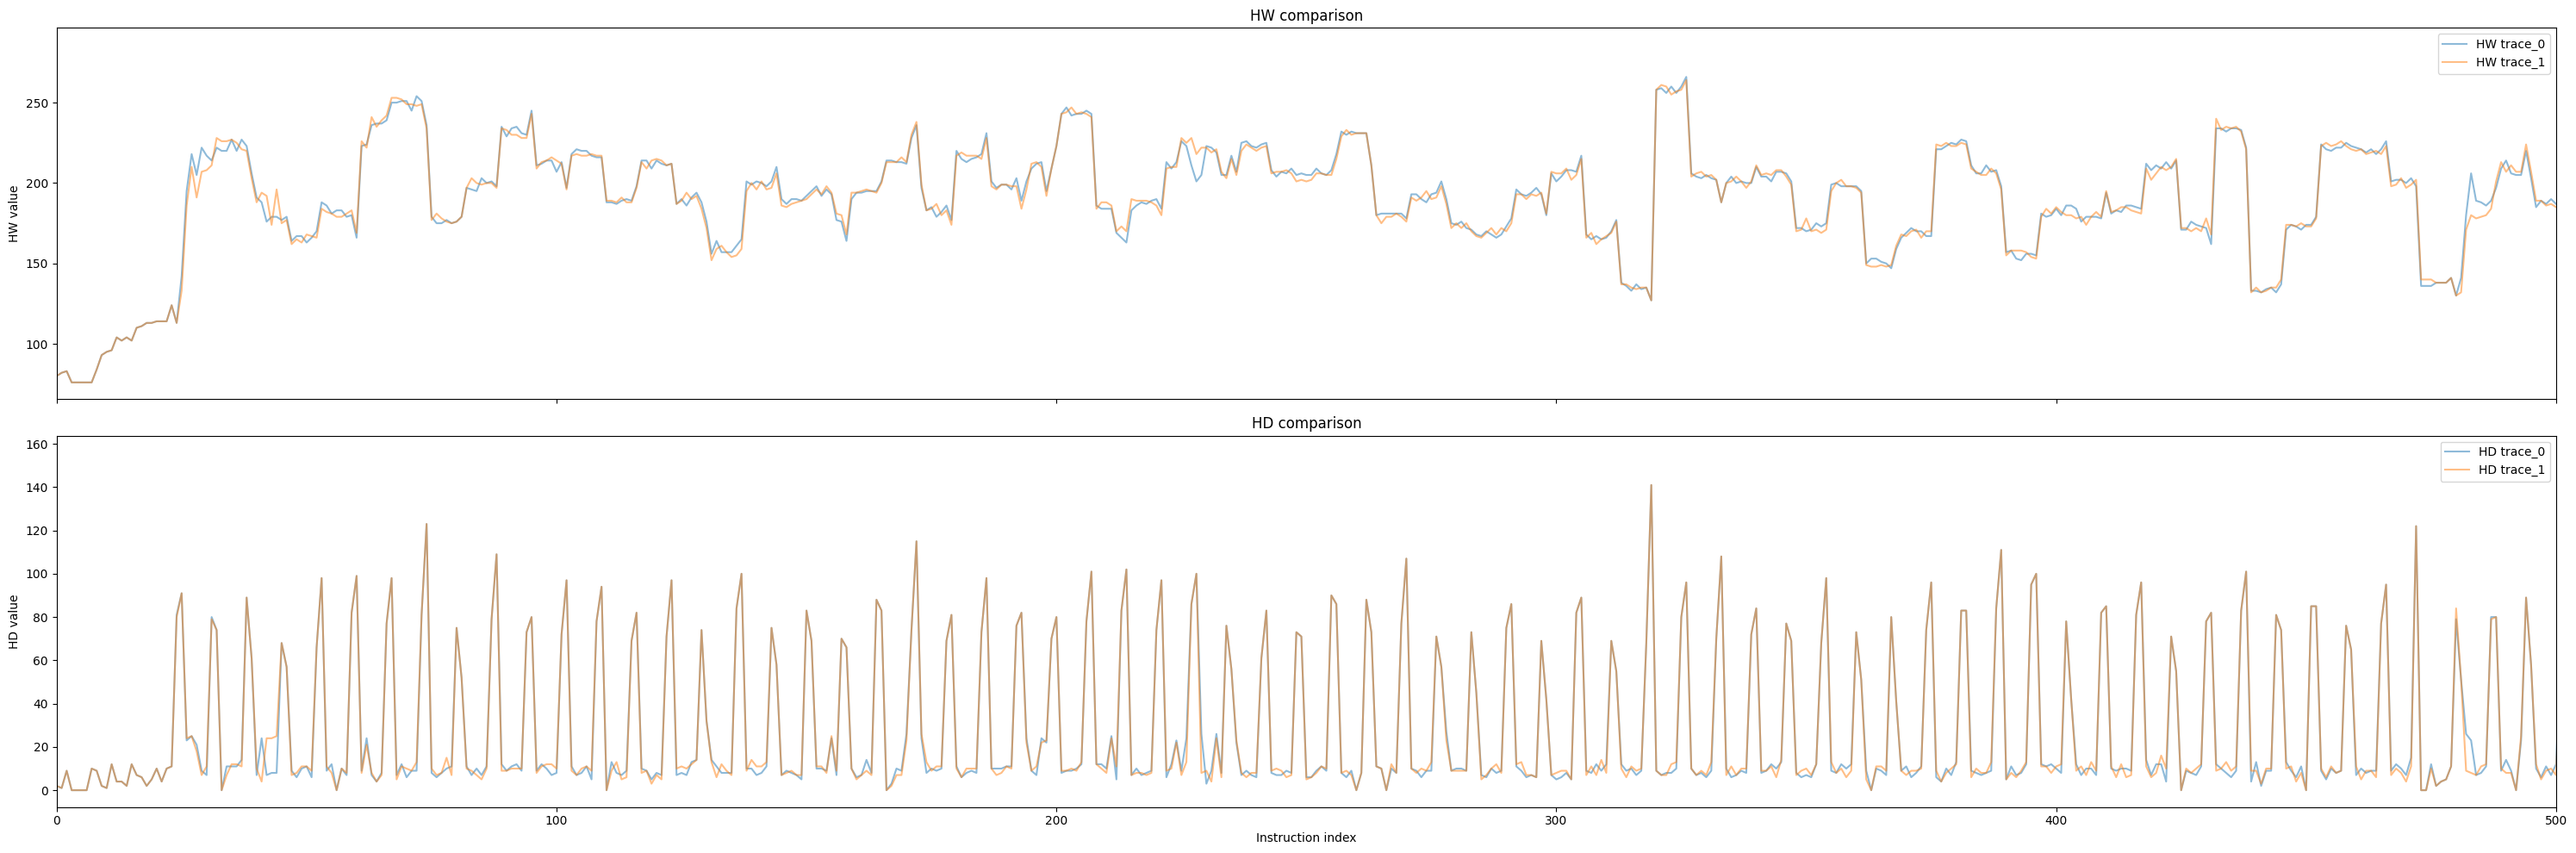

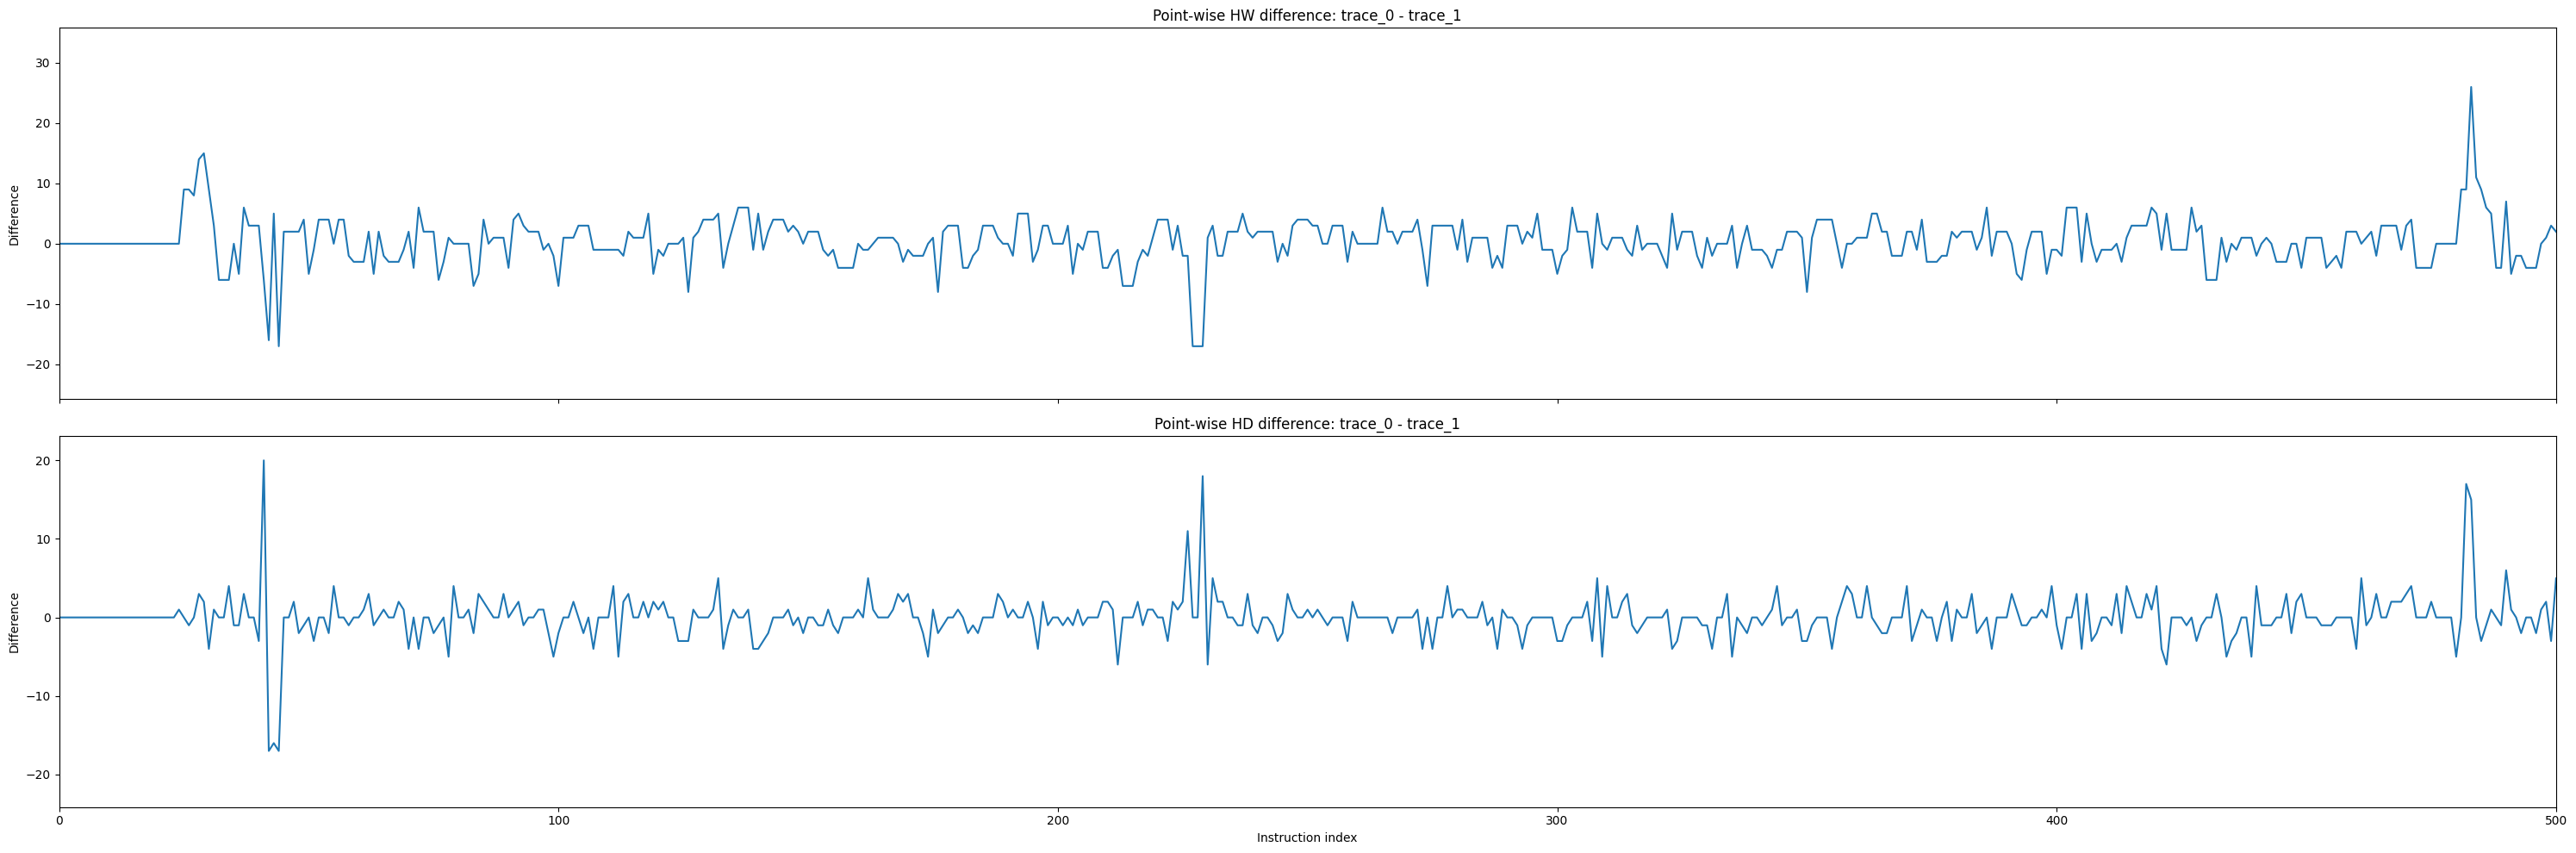

Correlation HW (0,1) = 0.9914
Correlation HW (0,128) = 0.4384
Correlation HW (0,256) = 0.3992
Correlation HW (0,480) = 0.4547
Correlation HW (0,620) = 0.6192
Correlation HD (0,1) = 0.9970
Correlation HD (0,128) = 0.8875
Correlation HD (0,256) = 0.8345
Correlation HD (0,480) = 0.7588
Correlation HD (0,620) = 0.9542


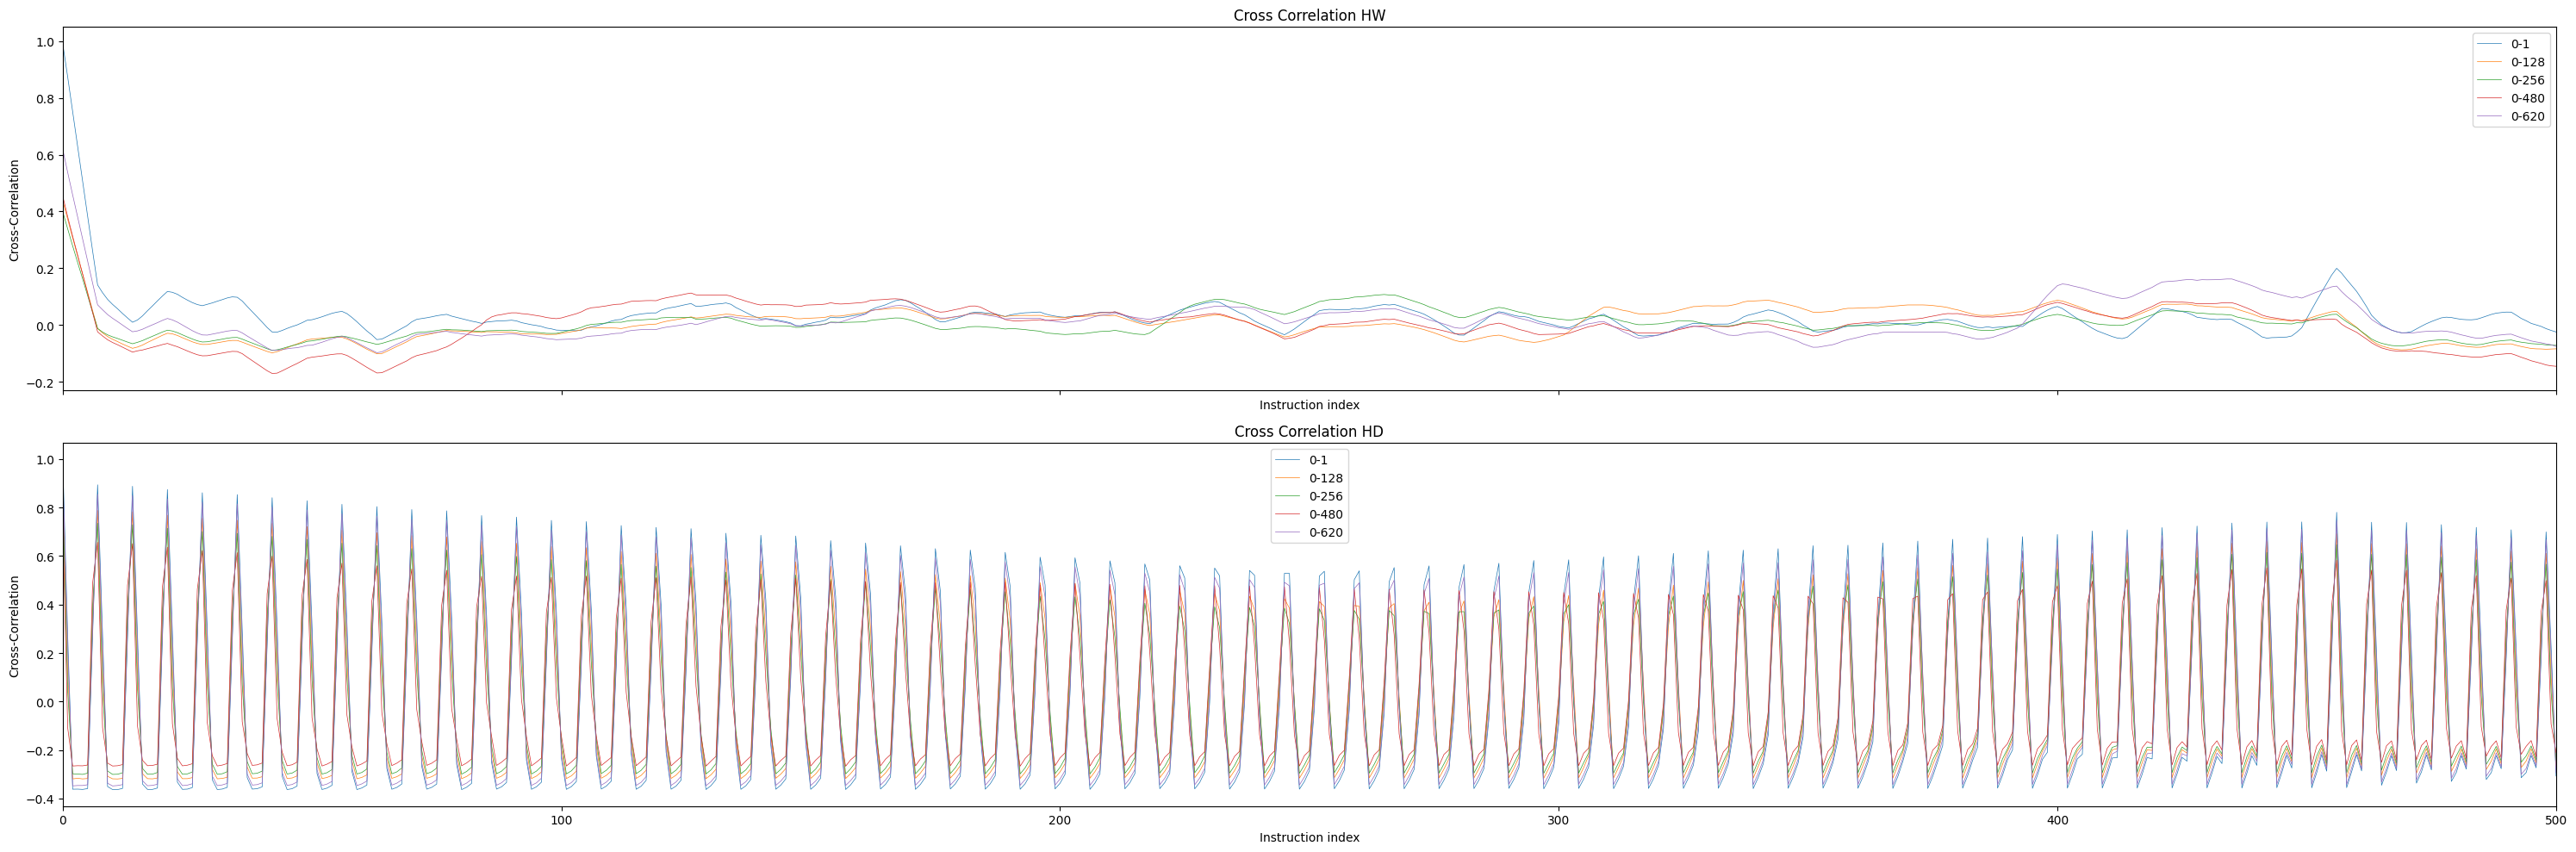

In [5]:
index1 = 0
index2 = 1
pairs = [(0, 1), (0, 128), (0, 256), (0, 480), (0, 620)]
plot_hw_hd_two_traces(data_HW, data_HD, index1, index2, save_path=os.path.join(result_dir, "hw_and_hd_traces_comparison.png"), no_instructions=no_instructions)
plot_hw_hd_difference(data_HW, data_HD, index1, index2, save_path=os.path.join(result_dir, "pointwise_difference.png"), no_instructions=no_instructions)
plot_cross_correlation_hw_hd(data_HW, data_HD, pairs, save_path=os.path.join(result_dir, "correlation_between_pairs.png"), no_instructions=no_instructions)
